**Author:** Adam Rozman  
**Contact:** arozman@bu.edu  
**Writeup:** [adrozman.github.io/2026/02/10/fft-fundamentals.html](https://adrozman.github.io/2026/02/10/fft-fundamentals.html)  

## Digital Signal Analysis using FFT
I will walk through the fundamentals of signal frequency analysis, explaining the *Fast Fourier Transform (FFT)* and working through examples in Python. The theory will be applied by constructing some signals and extracting their component frequencies using FFT. Finally, we'll discuss the issue of *spectral leakage* and mitigation strategies.

In [1]:
# We will need numpy, scipy, and matplotlib libraries.
import numpy as np
from scipy.signal.windows import hann
from matplotlib import pyplot as plt
# - OPTIONAL - I like this color palette
import seaborn as sbn
sbn.set_palette("colorblind")

## Sine wave review
$y = A sin(2\pi f t)$ ;   $A$ = Amplitude, $f$ = frequency

In [2]:
# Create a time array with one second duration, split into 500 points.
t = np.linspace(0,1, num=500)

# Make a signal with a 5 Hz frequency and amplitude of 3
y1 = 3*np.sin(2*np.pi*5*t)

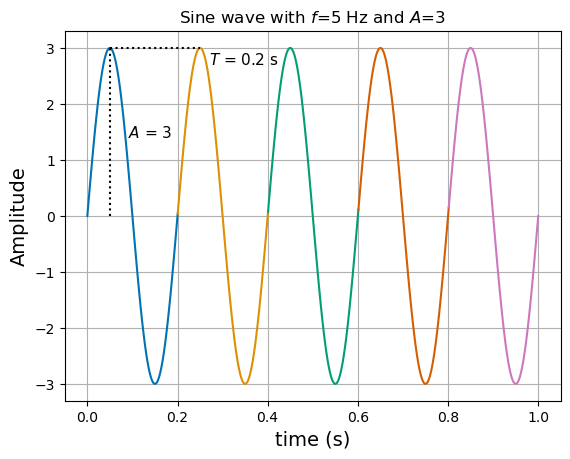

In [3]:
#@ plot the signal, one period at a time
plt.figure(figsize=(10, 5))
for i in range(5):
    plt.plot(t[100*i:100*(i+1)+1],y1[100*i:100*(i+1)+1])

# decorations for amplitude and period
plt.vlines(x=1/20,ymin=0,ymax=3,linestyle='dotted',color='k')  
plt.text(0.09,1.4,r"$A$ = 3",fontsize=11) 

plt.hlines(y=3,xmin=1/20,xmax=5/20,linestyle='dotted',color='k')  
plt.text(0.27,2.7,r"$T$ = 0.2 s",fontsize=11) 
 
plt.xlabel("time (s)", fontsize=14)
plt.ylabel("Amplitude", fontsize=14)
plt.grid(True)
plt.title(r"Sine wave with $f$=5 Hz and $A$=3")
plt.show()

In one second there are 5 cycles, each with an amplitude of 3. Each cycle has a period $T = 0.2 s$ following the relation $f = 1/T$. Let's make a more complicated signal.

In [4]:
# Make another signal with a 10 Hz frequency and amplitude of 5
y2 = 5*np.sin(2*np.pi*10*t + np.pi/3) # add some phase offset for fun

# Make another signal with 30 Hz frequency and amplitude of 3
y3 = 3*np.sin(2*np.pi*30*t) 

y = y1+y2+y3

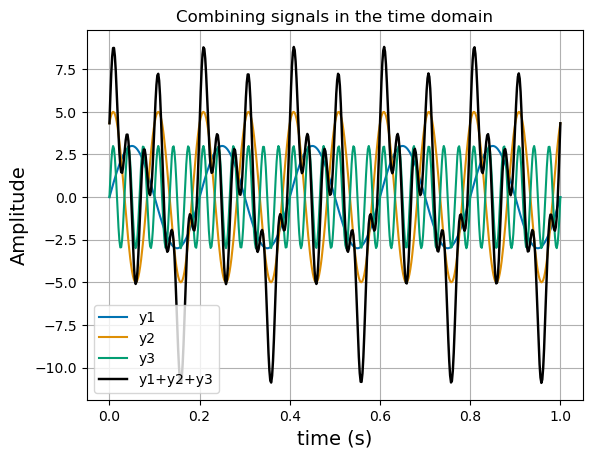

In [5]:
#@ plot the signal components and the sum
plt.figure(figsize=(10, 5))

plt.plot(t, y1)
plt.plot(t, y2)
plt.plot(t, y3)
plt.plot(t, y,color='k',linewidth=1.75)

plt.legend(["y1","y2","y3","y1+y2+y3"])
plt.xlabel("time (s)", fontsize=14)
plt.ylabel("Amplitude", fontsize=14)
plt.grid(True)
plt.title("Combining signals in the time domain")
plt.show()

When summing the three sine waves it becomes a fairly complex signal. We can see that it becomes more difficult to extract the frequency and amplitude of all the sine waves contained within. A real signal will contain nonzero amplitude across *all* the possible frequencies. To deal with this we use the concept of a **Fourier Transform** to convert a signal in time $f(t)$ to frequency
$f(\xi)$. It can be written for a continuous function as:

<center> $f(\xi)=\int_{-\infty}^{\infty} f(t)e^{-i2\pi \xi t}dt$ </center>

A **Fast Fourier Transform (FFT)** is an algorithm to perform a **Discrete Fourier
Transform (DFT)**, a numerical formulation that decomposes a signal in the time domain into sine waves with frequencies up to the Nyquist $f_{Nyquist}=\frac{1}{2\Delta t}=\frac{f_{sampling}}{2}$. The DFT is expressed as:

<center> $X_k = \sum_{n=0}^{N-1} x_n \cdot e^{-i2\pi \frac{kn}{N}}$ </center>

where $X_k$ is the complex amplitude of the sinusoidal component of signal $x$ at frequency $f=\frac{k}{N}$.

In [6]:
# Apply the fourier transform using numpy fft functions.
# learn more by reading the function documentation! https://numpy.org/devdocs/reference/generated/numpy.fft.fft.html
nt = len(t)
dt = t[1]-t[0]

spectrum = np.fft.fft(y)
fq = np.fft.fftfreq(nt,dt) # fftfreq function creates the fq array

print("FFT output is type: ", spectrum.dtype)

FFT output is type:  complex128


Like we expect from the equation above, the output $X_k$ is complex since it contains amplitude and phase for each frequency.

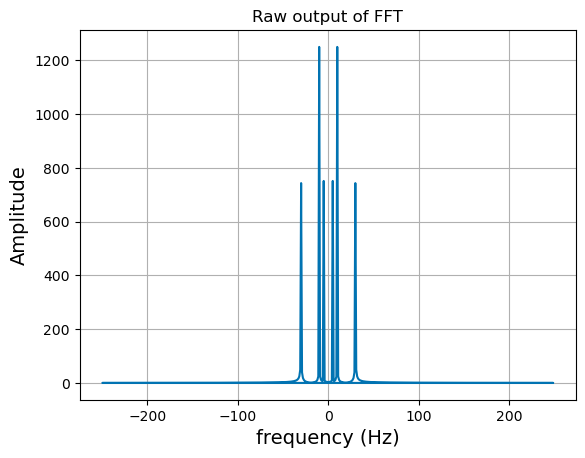

In [7]:
#@ Plot the raw FFT output
plt.figure(figsize=(10, 5))
plt.plot(fq,np.abs(spectrum))
plt.xlabel("frequency (Hz)", fontsize=14)
plt.ylabel("Amplitude", fontsize=14)
plt.grid(True)
plt.title("Raw output of FFT")
plt.show()

Looking at the raw output, we notice that there are negative frequencies with symmetry across $f=0$. This is because the FFT by default returns a *two-sided* spectrum. For an FFT of a real signal, the two sides are symmetrical, so we usually convert to a *one-sided* spectrum. We can get a one-sided spectrum by slicing away the second half representing the positive frequencies. Doing this, we have
to multiply the remaining spectrum by 2 to make up for the energy lost in the other half. 

Also notice that the amplitudes are over 1000, while we know they are no more than 5. This is because the output of the FFT algorithm is scaled by the number of points in the input array. Compensate for this by dividing the spectrum amplitudes by *nt*.

The phase $\phi$ of each wave is encoded into the real and imaginary components of the complex amplitudes as:

<center> $\phi = arctan(\frac{imag(X_k)}{real(X_k)})$ </center>

Since we want the total amplitude at each frequency and don't care about the phase for now, we take the magnitude of the complex amplitudes $|X_k|$. For signal processing, the phase information can usually be discarded unless the signal will be re-constructed as a time-series.

<center> $|X_k| = \sqrt{imag(X_k)^2 + real(X_k)^2}$ </center>

In [8]:
# Use only the first half of the fq and spectrum arrays
fq_onesided = fq[:nt//2]
# Multiply by 2 to make one-sided; divide by nt to undo FFT normalization; np.abs() produces magnitude.
spectrum_onesided = np.abs( spectrum[:nt//2] * 2 / nt )

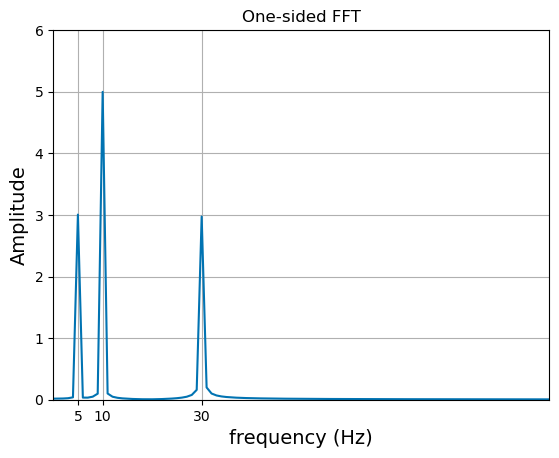

In [9]:
#@ Plot the FFT one-sided FFT spectrum, now scaled properly
plt.figure(figsize=(10, 5))
plt.plot(fq_onesided, spectrum_onesided)
plt.xticks([5,10,30])
plt.xlim(0,100)
plt.ylim(0,6)
plt.xlabel("frequency (Hz)", fontsize=14)
plt.ylabel("Amplitude", fontsize=14)
plt.grid(True)
plt.title("One-sided FFT")
plt.show()

You can see now that we have peaks at the correct frequency and amplitude of the input signal we created. 

### Review
To use the result of the FFT function, we convert it to a one-sided spectrum by slicing to just the first half of values ```[:nt//2]``` and multiplying by $2$ to compensate for the lost energy. We divide by ```nt``` to undo the FFT function's normalization, and we wrap it in ```np.abs()``` to get the magnitude of the complex amplitude.

```python
spectrum_onesided = np.abs( spectrum[:nt//2] * 2 / nt )
```

## Spectral leakage and mitigation strategy

The DFT works with the assumption of a periodic signal. The signal processed in the first example was perfectly periodic for all the frequencies contained; that will not be the case for more complex signals. We can simulate this by trimming our signal by a few points so that it is no longer periodic. I.e., if the signal is wrapped around end to start, there will be a jump discontinuity.

In [10]:
# Trim the signal to make it discontinuous in phase / aperiodic
t_trim = t[:-170]
y_trim = y[:-170]
nt = len(t_trim)

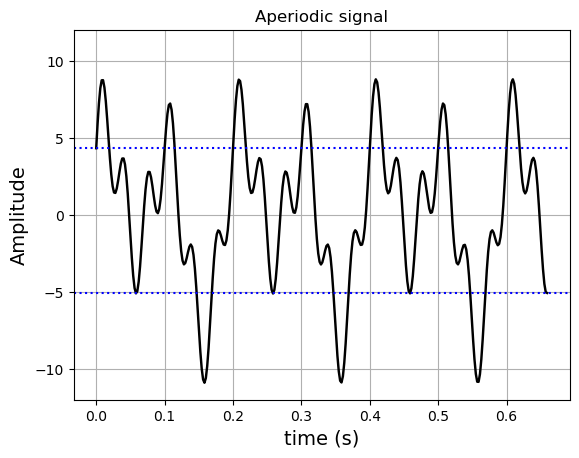

In [11]:
#@ Plot the aperiodic, discontinuous time-domain signal
plt.figure(figsize=(10, 5))
plt.plot(t_trim, y_trim,color='k',linewidth=1.75)

plt.axhline(y[0], linestyle='dotted', color='blue')
plt.axhline(y[-170-1], linestyle='dotted', color='blue')

plt.xlabel("time (s)", fontsize=14)
plt.ylabel("Amplitude", fontsize=14)
plt.ylim(-12,12)
plt.grid(True)
plt.title("Aperiodic signal")
plt.show()

In [12]:
# perform FFT on this discontinuous signal.
spectrum = np.abs(np.fft.fft(y_trim)[:nt//2] * 2 / nt)
fq = np.fft.fftfreq(nt,dt)[:nt//2] 

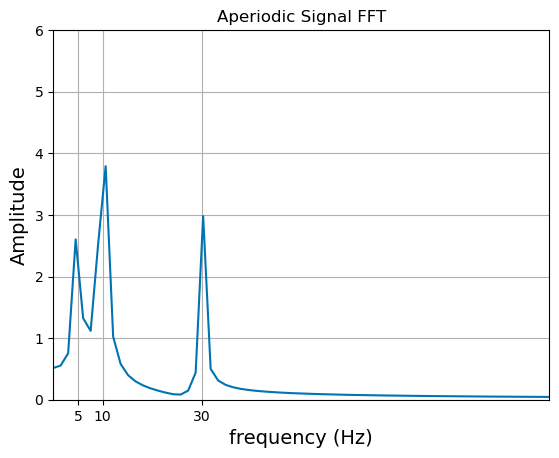

In [13]:
#@ Plot the raw FFT output
plt.figure(figsize=(10, 5))
plt.plot(fq,spectrum, label='Raw Signal')
plt.xticks([5,10,30])
plt.xlim(0,100)
plt.ylim(0,6)
plt.xlabel("frequency (Hz)", fontsize=14)
plt.ylabel("Amplitude", fontsize=14)
plt.grid(True)
# plt.legend()
plt.title("Aperiodic Signal FFT")
plt.show()

Here we exhibit *spectral leakage*. Because the FFT input was discontinuous, energy has "leaked" into the bins around the true frequencies of the signal, decreasing the amplitude of the desired frequencies.

We can reduce leakage  by applying *windowing*. Here is the signal multiplied by a hanning function, a curve that smoothly rises from 0 to 1 to 0 with a similar shape to a gaussian.


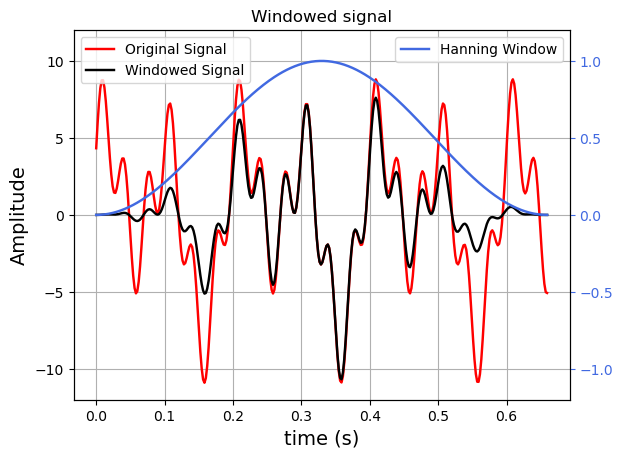

In [14]:
#@ Plot the window and windowed time-domain signal
fig, ax = plt.subplots(figsize=(10, 5))
plt.plot(t_trim, y_trim,color='r',linewidth=1.75)
ax.plot(t_trim, hann(nt)*y_trim,color='k',linewidth=1.75) 
ax.set_xlabel("time (s)", fontsize=14)
ax.set_ylabel("Amplitude", fontsize=14)
ax.set_ylim(-12,12)
ax.grid(True)
ax.legend(["Original Signal", "Windowed Signal"],loc='upper left')

ax2=ax.twinx()
ax2.plot(t_trim, hann(nt), color='royalblue',linewidth=1.75)
ax2.tick_params(axis='y', colors='royalblue')
ax2.yaxis.label.set_color('royalblue')
# ax2.set_ylabel("Hann Window Amplitude", fontsize=14)
ax2.set_ylim(-1.2,1.2)
ax2.legend(["Hanning Window"], loc='upper right')

plt.title("Windowed signal")
plt.show()

When we multiply the signal by our Hanning window, we are decreasing the energy in the signal and will therefore the amplitudes outputted by the FFT. To compensate for this, we divide the output by the average value of the windowing function to get the correct amplitudes. The Hanning window is convenient because its average value is 0.5, so the correction is to simply multiply the resulting spectrum by 2. A different correction factor is required for the power to be conserved, and is discussed in the acoustics processing post.

In [15]:
print("Hanning window average value: ", np.sum(hann(nt))/nt )

Hanning window average value:  0.4984848484848485


In [16]:
# We FFT the signal multiplied (element-wise) by the windowing function
spectrum_windowed = np.abs(np.fft.fft(hann(nt)*y_trim)[:nt//2] * 2 / nt)

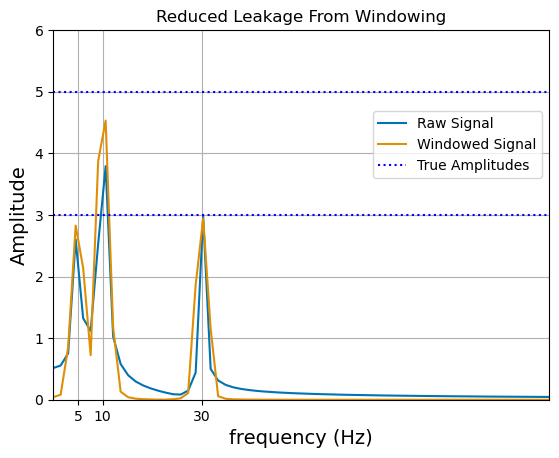

In [17]:
#@ Plot the FFT of the windowed and unwindowed signals
plt.figure(figsize=(10, 5))
plt.plot(fq,spectrum, label='Raw Signal')
plt.plot(fq,spectrum_windowed*2, label='Windowed Signal')
plt.axhline(5,linestyle='dotted',color='blue',label='True Amplitudes')
plt.axhline(3,linestyle='dotted',color='blue')
plt.xticks([5,10,30])
plt.xlim(0,100)
plt.ylim(0,6)
plt.xlabel("frequency (Hz)", fontsize=14)
plt.ylabel("Amplitude", fontsize=14)
plt.grid(True)
plt.legend(loc='upper right', bbox_to_anchor=(1.0, .8))
plt.title("Reduced Leakage From Windowing")
plt.show()

We have improved the accuracy of the predicted peaks of our discontinuous/aperiodic signal using windowing. However, there is still error from the true values. Obtaining more samples, creating a longer signal, also reduces leakage.